# Imports

In [2]:
!pip install tqdm

In [4]:
!pip install gspread_dataframe

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pickle
from scipy.optimize import curve_fit
import pandas as pd
from scipy.stats import rv_continuous
from scipy.special import gamma, pbdv
from tqdm import tqdm
from scipy.integrate import cumulative_trapezoid
import gspread
from gspread_dataframe import get_as_dataframe
from oauth2client.service_account import ServiceAccountCredentials
from scipy.interpolate import Akima1DInterpolator

In [2]:
%load_ext autoreload
%autoreload 2
from pdf import pdf_cosmic 

# Konietzka Notebook

In [5]:
name_continuous = 'Konietzka2025_DMmap_continuous_v1.hdf5'
with h5py.File(name_continuous, 'r') as file:
    # load the data
    DM_continuous = file['DMvalues'][:, ::10]      # This will downsample while reading
    z_continuous  = file['redshifts'][:]

In [4]:
def find_index(redshift, redshifts):
    """
    takes the target redshift and the redshifts array (e.g., z_continuous)
    returns index
    """
    index = np.where(np.round(redshifts,3)==np.round(redshift,3))[0][0]
    return index

In [5]:
z_target = 1.0
index_1 = find_index(z_target, z_continuous)
print(index_1)

99


In [6]:
DM_1 = DM_continuous[index_1, :]

(600.0, 1800.0)

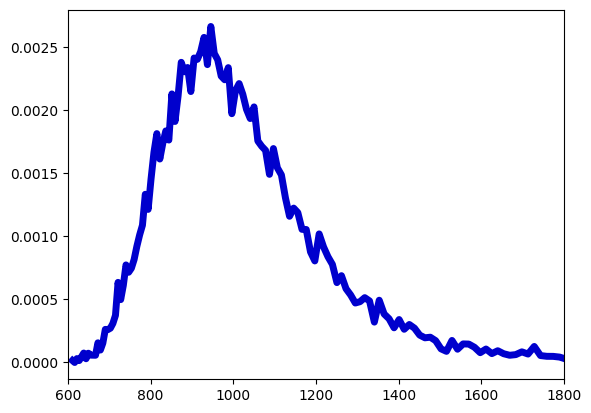

In [7]:
plt.figure()

min_DM, max_DM = np.min(DM_1), np.max(DM_1)
log_bins = np.logspace(np.log10(min_DM), np.log10(max_DM), 200)
hist, bin_edges = np.histogram(DM_1, bins=log_bins, density=True)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

plt.plot(bin_centers, hist, c='mediumblue', linewidth=5)
plt.xlim(600, 1800)

(0.0, 0.017)

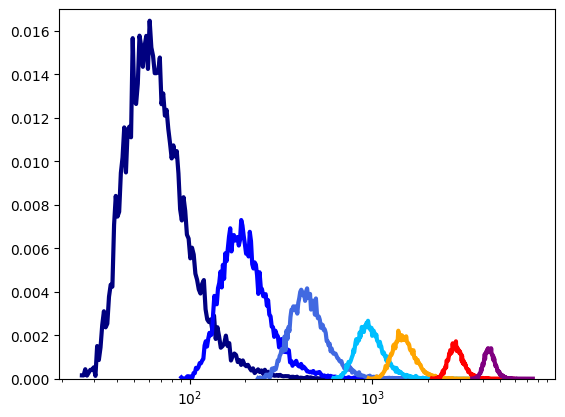

In [8]:
plt.figure()

colors = ['navy', 'blue', 'royalblue', 'deepskyblue', 'orange', 'red', 'purple']
for idx, redshift in enumerate([0.1, 0.25, 0.5, 1.0, 1.5, 3.0, 5.0]):
    
    # find index
    index_z = find_index(redshift, z_continuous)
    
    # get DM
    DM_z = DM_continuous[index_z, :]
    
    min_DM, max_DM = np.min(DM_z), np.max(DM_z)
    log_bins = np.logspace(np.log10(min_DM), np.log10(max_DM), 200)
    hist, bin_edges = np.histogram(DM_z, bins=log_bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    plt.plot(bin_centers, hist, c=colors[idx], linewidth=3)

plt.xscale('log')
plt.ylim(0, 0.017)

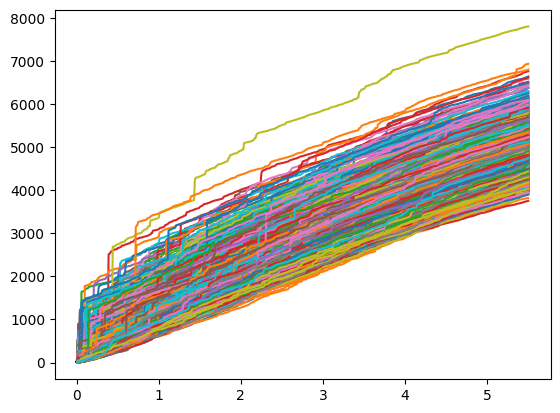

In [9]:
plt.plot(z_continuous, DM_continuous)
plt.show()

# Finding Sigma and Mu

In [21]:
class p_np31(rv_continuous):
    def _pdf(self, DM, sigma, mu):
        alpha=1
        beta=3.3
        eta=mu/(np.sqrt(2)*sigma*alpha)
        delta=(beta-1)/alpha
        log_c_inv=np.log(mu / alpha) -(eta**2)/2-delta*np.log(mu/(alpha*sigma))+np.log(gamma(delta))+np.log(pbdv(-delta, -np.sqrt(2)*eta)[0])

        pdf_cosmic= np.exp(-(mu**2*((mu/DM)**alpha-1)**2)/(2*sigma**2*alpha**2)-beta*np.log(DM/mu)-log_c_inv)
        return pdf_cosmic
sigmas=[]
mus=[]
for zi in tqdm(range(550)):
    dist = p_np31(a=0)

    # Assume dat = array of values
    sigma, mu, *_ = dist.fit(DM_continuous[zi], floc=0, fscale=1)
    sigmas.append(sigma)
    mus.append(mu)
    
    
with open('fit_results.pkl', 'wb') as f:
    pickle.dump({'sigmas': sigmas, 'mus': mus}, f)

100%|██████████| 550/550 [12:23:19<00:00, 81.09s/it]  


In [2]:
with open('fit_results.pkl', 'rb') as f:
    data = pickle.load(f)

sigmas = data['sigmas']
mus = data['mus']

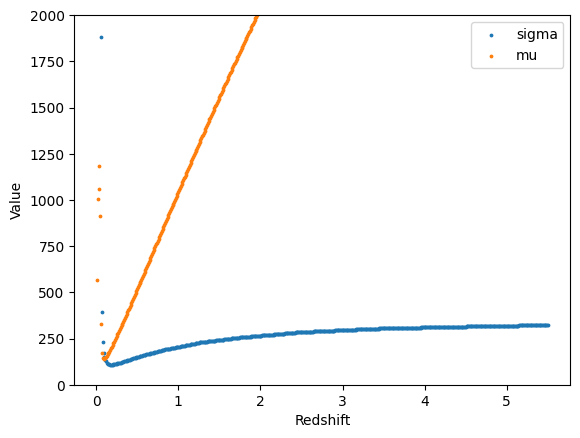

In [6]:
plt.scatter(z_continuous, sigmas, label="sigma", s=3)
plt.scatter(z_continuous, mus, label="mu", s=3)
plt.legend()
plt.xlabel("Redshift")
plt.ylabel("Value")
plt.ylim(0,2000)
plt.show()

In [53]:
np.where(z_continuous==1.0)

(array([99]),)

In [96]:
print(sigmas[99])
print(mus[99])

204.8134746990548
1043.5400228789476


In [4]:
def poly(x,a,b,c,d,e):
    return a*x**4+b*x**3+c*x**2+d*x+e

In [9]:
sigma_fit=curve_fit(poly, z_continuous[17:], sigmas[17:], p0=[1,1,1,1,1])

In [85]:
print(sigma_fit)

(array([ -0.51118026,   8.62170312, -56.35019904, 179.39425529,
        73.17020344]), array([[ 1.26025434e-04, -1.43164894e-03,  5.33164101e-03,
        -7.18950570e-03,  2.55551176e-03],
       [-1.43164894e-03,  1.64908363e-02, -6.25040748e-02,
         8.62042100e-02, -3.14864575e-02],
       [ 5.33164101e-03, -6.25040748e-02,  2.42476004e-01,
        -3.45125303e-01,  1.31402829e-01],
       [-7.18950570e-03,  8.62042100e-02, -3.45125303e-01,
         5.14662131e-01, -2.10413528e-01],
       [ 2.55551176e-03, -3.14864575e-02,  1.31402829e-01,
        -2.10413528e-01,  1.00034043e-01]]))


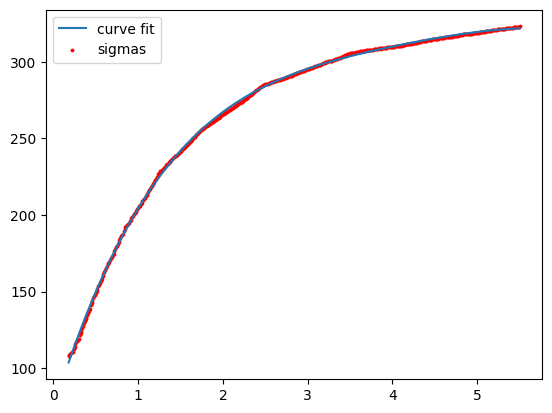

In [10]:
plt.plot(z_continuous[17:], poly(z_continuous[17:], sigma_fit[0][0], sigma_fit[0][1], sigma_fit[0][2], sigma_fit[0][3], sigma_fit[0][4]), label="curve fit")
plt.scatter(z_continuous[17:], sigmas[17:],s=3, color="red", label="sigmas")
plt.legend()
plt.show()

In [11]:
mu_fit=curve_fit(poly, z_continuous[17:], mus[17:], p0=[1,1,1,1,1])

In [90]:
print(mu_fit)

(array([ 4.84078705e-01, -5.27830670e+00, -2.87468649e+01,  1.10353727e+03,
       -2.25990821e+01]), array([[ 2.07981563e-03, -2.36267053e-02,  8.79888323e-02,
        -1.18649450e-01,  4.21739854e-02],
       [-2.36267053e-02,  2.72150599e-01, -1.03151361e+00,
         1.42264039e+00, -5.19625553e-01],
       [ 8.79888323e-02, -1.03151361e+00,  4.00161596e+00,
        -5.69565210e+00,  2.16855972e+00],
       [-1.18649450e-01,  1.42264039e+00, -5.69565210e+00,
         8.49354243e+00, -3.47248425e+00],
       [ 4.21739854e-02, -5.19625553e-01,  2.16855972e+00,
        -3.47248425e+00,  1.65087560e+00]]))


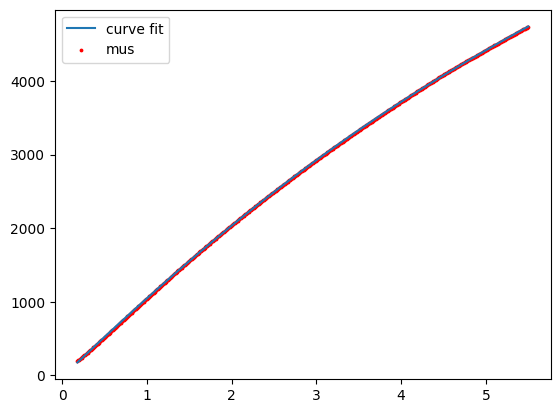

In [12]:
plt.plot(z_continuous[17:], poly(z_continuous[17:], mu_fit[0][0], mu_fit[0][1], mu_fit[0][2], mu_fit[0][3], mu_fit[0][4]), label="curve fit")
plt.scatter(z_continuous[17:], mus[17:],s=3, color="red", label="mus")
plt.legend()
plt.show()

In [13]:
poly(1.0, mu_fit[0][0],mu_fit[0][1], mu_fit[0][2], mu_fit[0][3], mu_fit[0][4])

1047.3970916150893

In [14]:
poly(1.0, sigma_fit[0][0],sigma_fit[0][1], sigma_fit[0][2], sigma_fit[0][3], sigma_fit[0][4])

204.324782542426

In [97]:
print(z_continuous.shape)

(550,)


In [16]:
df = pd.read_csv("best_fit_values_Konietzka25_DMcos.csv")
mus_2=df["mu"].values
sigmas_2=df["sigma"].values
redshift=df["z"].values

mu_fit_2=curve_fit(poly, redshift, mus_2, p0=[1,1,1,1,1])
sigma_fit_2=curve_fit(poly, redshift[1:], sigmas_2[1:], p0=[1,1,1,1,1])

print(sigma_fit_2)

(array([ -0.23051519,   5.041934  , -40.24850368, 148.61916293,
        80.46481831]), array([[ 1.54734264e-03, -1.76397060e-02,  6.57554304e-02,
        -8.82489322e-02,  3.06930925e-02],
       [-1.76397060e-02,  2.03941722e-01, -7.73971490e-01,
         1.06301077e+00, -3.80366978e-01],
       [ 6.57554304e-02, -7.73971490e-01,  3.00792275e+00,
        -4.26766864e+00,  1.59511990e+00],
       [-8.82489322e-02,  1.06301077e+00, -4.26766864e+00,
         6.35567477e+00, -2.56197201e+00],
       [ 3.06930925e-02, -3.80366978e-01,  1.59511990e+00,
        -2.56197201e+00,  1.21625157e+00]]))


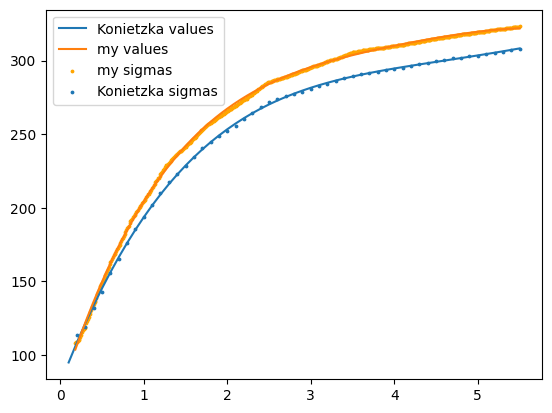

In [17]:
plt.plot(redshift,poly(redshift,*sigma_fit_2[0]), label="Konietzka values")
plt.plot(z_continuous[17:], poly(z_continuous[17:], sigma_fit[0][0], sigma_fit[0][1], sigma_fit[0][2], sigma_fit[0][3], sigma_fit[0][4]), label="my values")
plt.scatter(z_continuous[17:], sigmas[17:],s=3, color="orange", label="my sigmas")
plt.scatter(redshift[1:], sigmas_2[1:],s=3, label="Konietzka sigmas")
plt.legend()
plt.show()

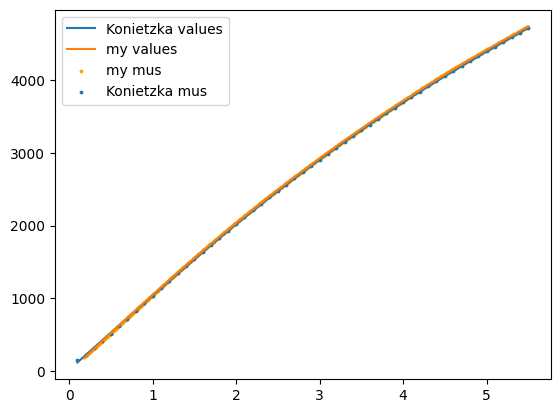

In [19]:
plt.plot(redshift,poly(redshift,*mu_fit_2[0]), label="Konietzka values")
plt.plot(z_continuous[17:], poly(z_continuous[17:], *mu_fit[0]), label="my values")
plt.scatter(z_continuous[17:], mus[17:],s=3, color="orange", label="my mus")
plt.scatter(redshift, mus_2,s=3, label="Konietzka mus")
plt.legend()
plt.show()

# Plotting PDF and Outcat values

In [3]:
dm_c=np.linspace(0.01, 6500, 5000)
red=np.linspace(0.01,5.5,5000)

cosmic=pdf_cosmic(dm_c,red,"best_fit_values_Konietzka25_DMcos.csv")

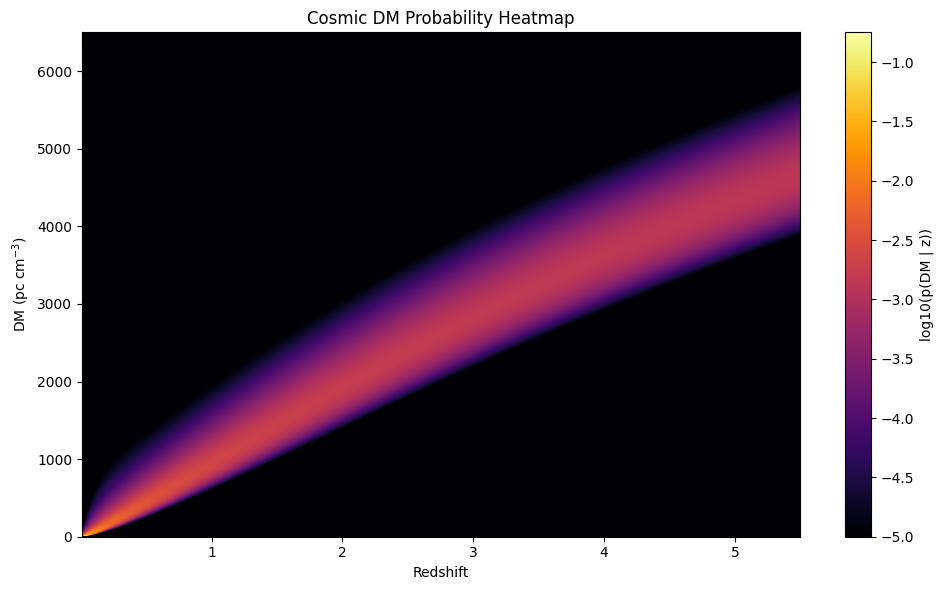

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmin=-5,vmax=-0.75
)

plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.tight_layout()
plt.show()

In [45]:
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("/arc/projects/chime_frb/rdarlinger/flash-asset-289501-546b8de133d9.json", scope)
client = gspread.authorize(creds)

sheet = client.open("outrigger burst properties").worksheet("outcat1+2")
df = get_as_dataframe(sheet)

In [46]:
df.columns = df.iloc[0]        # set real headers
df = df.drop(index=0).reset_index(drop=True)

silver_start = df[df['Event ID'] == 'Silver'].index[0]
silver_header = silver_start + 1  # the repeated header row

# Split
gold_df = df.iloc[:silver_start].copy()
silver_df = df.iloc[silver_header+1:].copy()  # skip both Silver row and its header
silver_df.columns = df.iloc[silver_header]     # set column names from the header row
silver_df = silver_df.reset_index(drop=True)

# Extract redshifts
gold_redshifts = pd.to_numeric(gold_df['redshift'], errors='coerce').dropna()
silver_redshifts = pd.to_numeric(silver_df['redshift'], errors='coerce').dropna()

#df["redshift"] = pd.to_numeric(df["redshift"], errors="coerce")
#df_clean = df.dropna(subset=["DM (DM_phase)", "DM_MW (NE2025)", "redshift"])
#mask1 = df_clean["Sample"].isin(["outcat1"])
#mask2= df_clean["Sample"].isin(["outcat2"])

#dm_1      = df_clean.loc[mask1, "DM (DM_phase)"].to_numpy()    
#dm_mw_1   = df_clean.loc[mask1, "DM_MW (NE2025)"].to_numpy()
#z_1       = df_clean.loc[mask1, "redshift"].to_numpy()
#dm_2      = df_clean.loc[mask2, "DM (DM_phase)"].to_numpy()    
#dm_mw_2   = df_clean.loc[mask2, "DM_MW (NE2025)"].to_numpy()
#z_2       = df_clean.loc[mask2, "redshift"].to_numpy()
#dm_ex_1=dm_1-dm_mw_1-30
#dm_ex_2=dm_2-dm_mw_2-30

0     0.057868
1     0.107500
2     0.068900
4     0.055300
5     0.115400
7     0.019000
8     0.094900
10    0.044700
11    0.098100
12    0.066300
13    0.149200
14    0.071300
15    0.240400
16    0.167800
17    0.368700
18    0.122300
19    0.110000
21    0.078300
22    0.286200
23    0.118400
24    0.374300
27    0.161400
28    0.196100
30    0.105800
31    0.045500
32    0.205000
33    0.413200
34    0.134600
35    0.182300
36    0.072900
38    0.230400
40    0.146400
41    0.135100
42    0.026300
43    0.029600
44    0.079700
45    0.292500
46    0.120600
48    0.287200
49    0.115900
50    0.064400
Name: redshift, dtype: float64
2     0.2115
7     0.3705
11    0.1421
13    0.1254
16    0.2450
18    0.1119
Name: redshift, dtype: float64


In [11]:
print(len(dm_1))
print(len(dm_2))

13
28


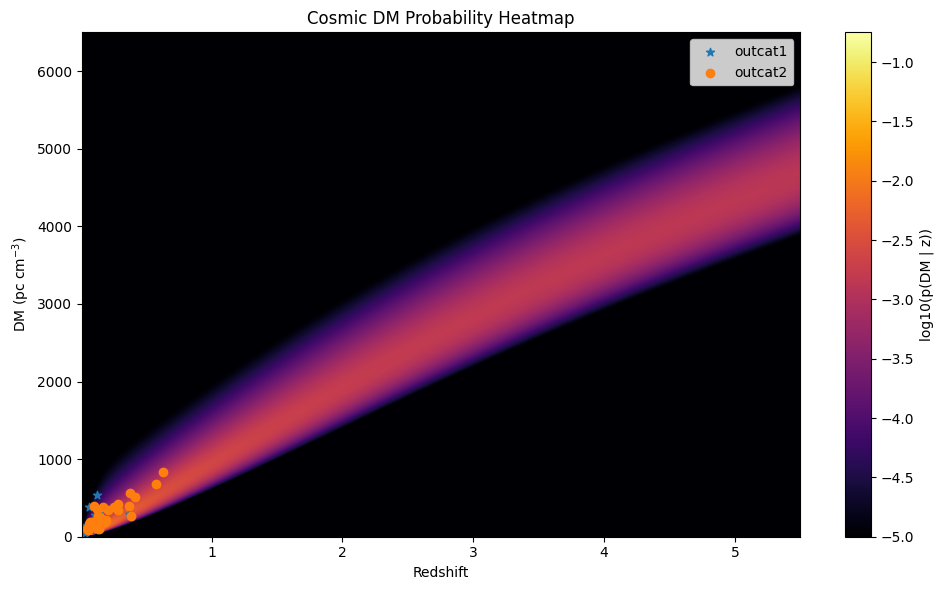

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmin=-5,vmax=-0.75
)
plt.colorbar(im, ax=ax, label="log10(p(DM | z))")

plt.scatter(z_1,dm_ex_1, marker="*", label="outcat1")
plt.scatter(z_2,dm_ex_2, label='outcat2')
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

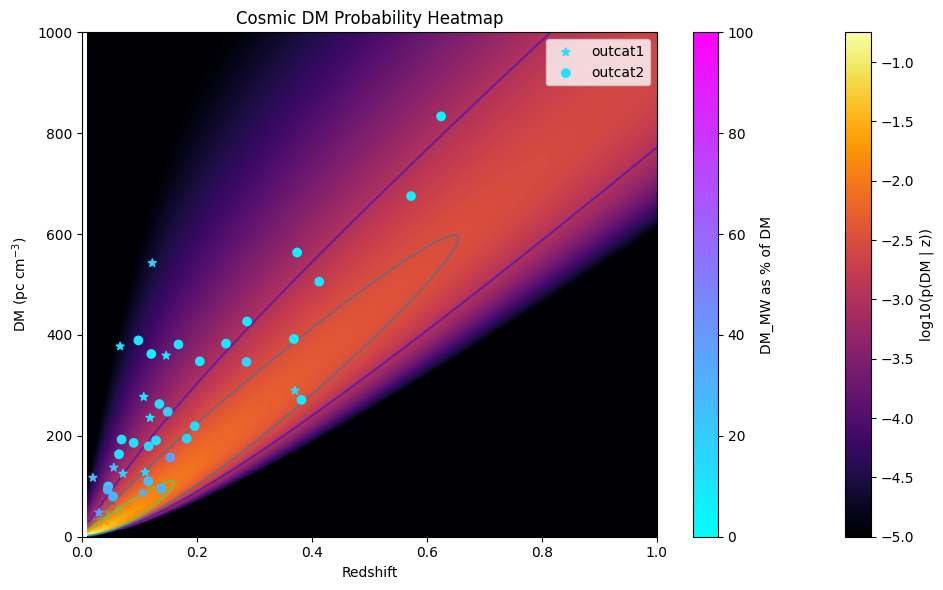

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
contours=ax.contour(red, dm_c, np.log10(cosmic+1e-32), levels=[-3,-2.5,-2],  cmap="winter",alpha=0.4)
ax.clabel(contours, levels=[-3,-2.5,-2], inline=False)
pct_1 = (dm_mw_1 / dm_1) * 100
pct_2 = (dm_mw_2 / dm_2) * 100

scatter1 = ax.scatter(z_1, dm_ex_1, marker="*", c=pct_1, cmap="cool", vmin=0, vmax=100, label="outcat1", zorder=5)
scatter2 = ax.scatter(z_2, dm_ex_2, c=pct_2, cmap="cool", vmin=0, vmax=100, label="outcat2", zorder=5)
plt.colorbar(scatter1, ax=ax, label="DM_MW as % of DM")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.xlim(0,1)
plt.ylim(0,1000)
plt.show()

In [40]:
print(pct_1<40)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False]


In [41]:
print(pct_2<40)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False  True  True  True  True  True  True]


In [42]:
print(pct_1[-1])

40.53909822311574


In [43]:
print(pct_2[26])

50.63463050475171


Using z = 0.3999


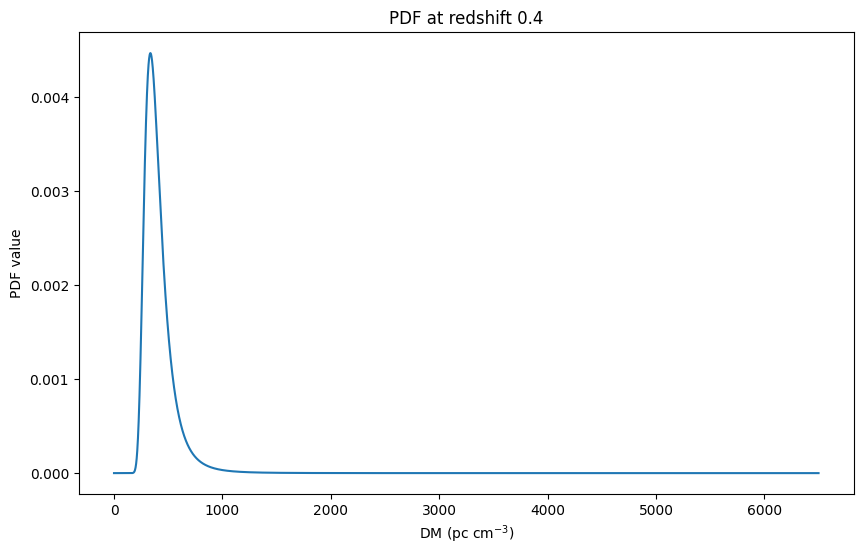

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
j = np.argmin(np.abs(red - 0.4))
print(f"Using z = {red[j]:.4f}") 

# Extract the slice
prob_slice = cosmic[:, j] + 1e-32

plt.plot(dm_c, prob_slice)
plt.xlabel("DM (pc cm$^{-3})$")
plt.ylabel("PDF value")
plt.title("PDF at redshift 0.4")
plt.show()

In [57]:
mean_1=np.sum(prob_slice*dm_c*(dm_c[1]-dm_c[0]))
print(mean_1)

409.7913174431165


In [59]:
std_1=np.sqrt(np.sum(prob_slice*(dm_c-mean)**2*(dm_c[1]-dm_c[0])))
print(std_1)

4311.728206865844


In [53]:
print(prob_slice[500])
print(np.sum(prob_slice))

0.00038641921210170235
0.7690699898553274


In [22]:
from scipy.integrate import trapezoid
cdf_z0 = trapezoid(prob_slice, dm_c)

In [23]:
print(cdf_z0)

0.999989443657803


# CDF and Shape of Cliff

In [6]:
cliff_values=[]
cdf_values=[]
z_values=[]
means=[]
sds=[]
for redshift in np.arange(0.01,5.51,0.01):
    j=np.argmin(np.abs(red - redshift))
    pdf_z0 = cosmic[:, j]
    dx=dm_c[1]-dm_c[0]
    mean=np.sum(cosmic[:,j]*dm_c*dx)
    means.append(mean)
    sds.append(np.sqrt(np.sum(cosmic[:,j]*(dm_c-mean)**2*dx)))
    z_values.append(red[j])
    cdf_z0 = cumulative_trapezoid(pdf_z0, dm_c, initial=0)
    cdf_z0/= cdf_z0[-1]
    cdf_values.append(cdf_z0)
    cdf_target = 0.05 
    dm_value = np.interp(cdf_target, cdf_z0, dm_c)
    cliff_values.append(dm_value)

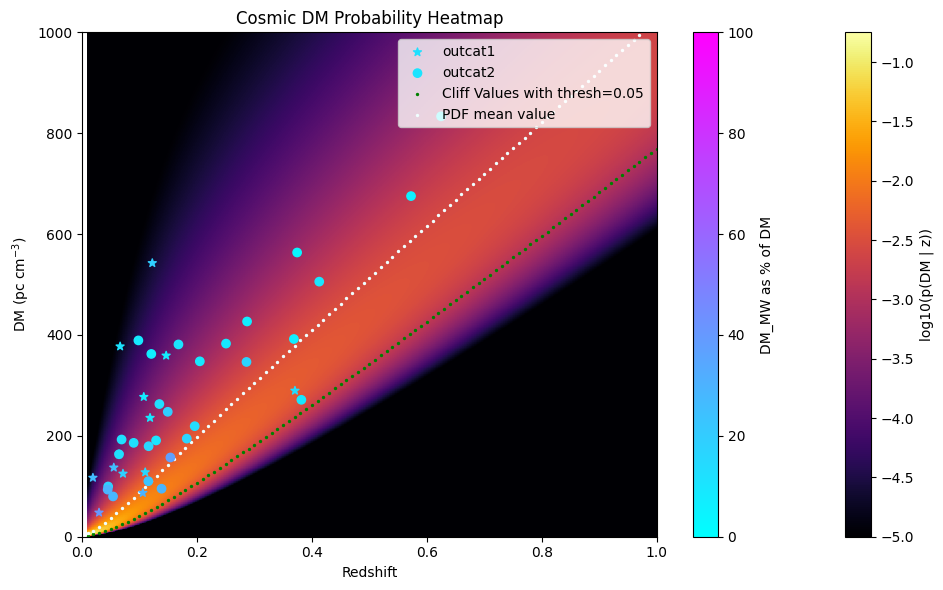

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
pct_1 = (dm_mw_1 / dm_1) * 100
pct_2 = (dm_mw_2 / dm_2) * 100

scatter1 = ax.scatter(z_1, dm_ex_1, marker="*", c=pct_1, cmap="cool", vmin=0, vmax=100, label="outcat1", zorder=5)
scatter2 = ax.scatter(z_2, dm_ex_2, c=pct_2, cmap="cool", vmin=0, vmax=100, label="outcat2", zorder=5)
scatter3= ax.scatter(np.arange(0.01,5.51,0.01),cliff_values, s=2, color="green", label="Cliff Values with thresh=0.05")
scatter4=ax.scatter(np.arange(0.01,5.51,0.01), means, s=2, color="azure", label="PDF mean value")
plt.colorbar(scatter1, ax=ax, label="DM_MW as % of DM")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.xlim(0,1)
plt.ylim(0,1000)
plt.show()

In [86]:
def cube(x,a,b,c,d):
    return a*x**3+b*x**2+c*x+d

In [88]:
cliff_fit=curve_fit(cube, np.arange(0.01,5.51,0.01), cliff_values, p0=[1,1,1,1], bounds=(0, np.inf))

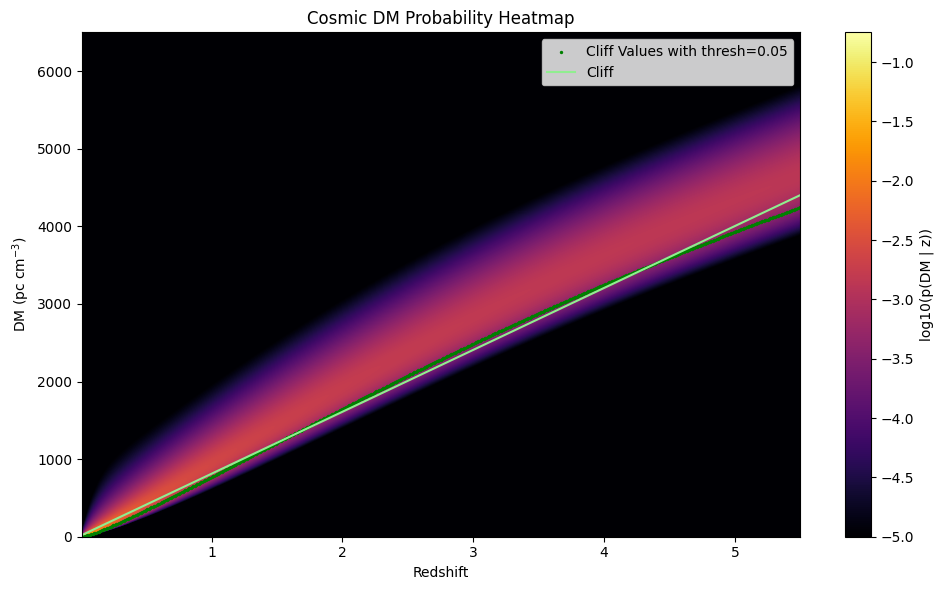

In [90]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
scatter1= ax.scatter(np.arange(0.01,5.51,0.01),cliff_values, s=2, color="green", label="Cliff Values with thresh=0.05")
plt.plot(red,cube(red,*cliff_fit[0]), color="lightgreen", label="Cliff")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [95]:
cliff_fit_2= Akima1DInterpolator(np.arange(0.01,5.51,0.01), cliff_values)

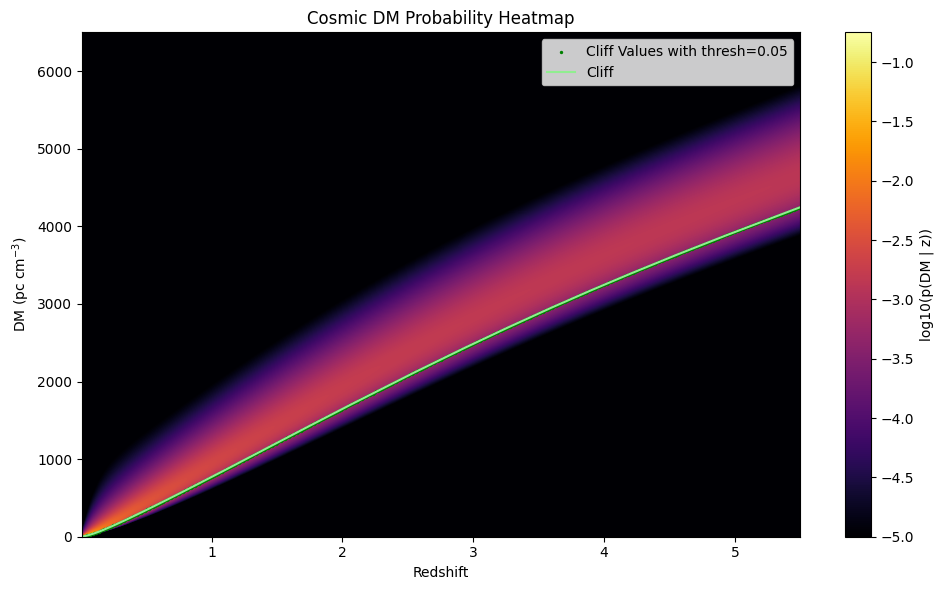

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
scatter1= ax.scatter(np.arange(0.01,5.51,0.01),cliff_values, s=2, color="green", label="Cliff Values with thresh=0.05")
cliff_line = cliff_fit_2(red)
plt.plot(red, cliff_line, color="lightgreen", label="Cliff")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [21]:
def power_law(x, a, b):
    return a * x**b

cliff_fit_3 = curve_fit(power_law, np.arange(0.01, 1.51, 0.01), cliff_values[:150])
print(cliff_fit_3)

(array([764.57607193,   1.1528761 ]), array([[ 4.18289939e-01, -5.65606261e-04],
       [-5.65606261e-04,  6.96055597e-06]]))


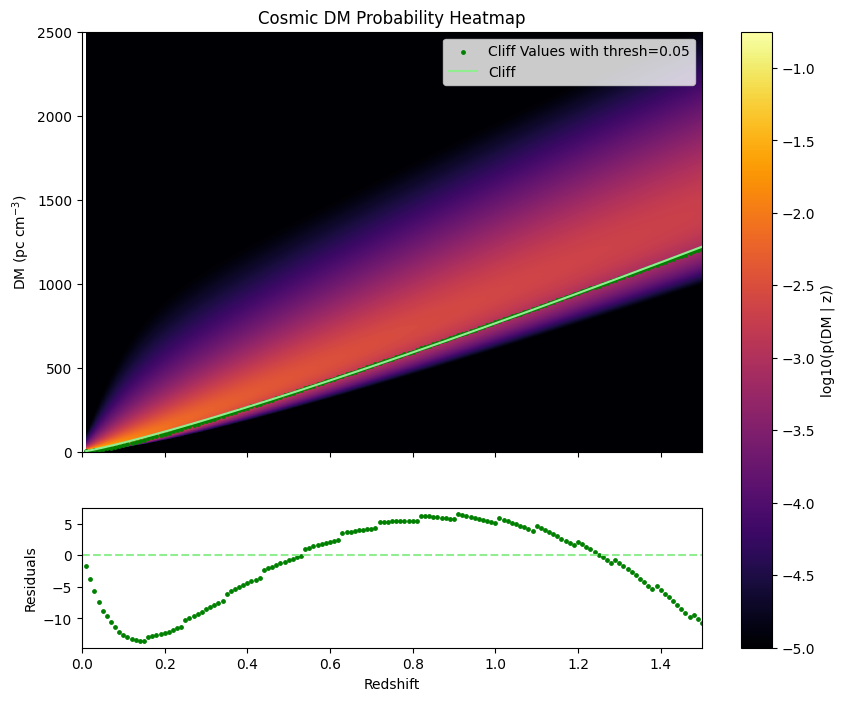

In [22]:
fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(10, 8),
                                   sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno", shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=[ax, ax_res], label="log10(p(DM | z))", location='right')
scatter1 = ax.scatter(np.arange(0.01,1.51,0.01), cliff_values[:150], s=6, color="green", label="Cliff Values with thresh=0.05")
ax.plot(red, power_law(red, *cliff_fit_3[0]), color="lightgreen", label="Cliff")
ax.set_ylabel("DM (pc cm$^{-3}$)")
ax.set_title("Cosmic DM Probability Heatmap")
ax.legend(loc="upper right")
ax.set_ylim(0, 2500)

# Residuals
z_fit = np.arange(0.01, 1.51, 0.01)
residuals = cliff_values[:150] - power_law(z_fit, *cliff_fit_3[0])
ax_res.scatter(z_fit, residuals, s=6, color="green")
ax_res.axhline(0, color="lightgreen", linestyle="--")
ax_res.set_ylabel("Residuals")
ax_res.set_xlabel("Redshift")

ax.set_xlim(0, 1.5)
ax_res.set_xlim(0, 1.5)
plt.show()

In [25]:
np.where(np.arange(0.01,5.51,0.01)==1.5)

(array([149]),)

In [8]:
def power_law_quad_correct(x, a, b, c):
    return a * x**b + c * x**2
cliff_fit_4 = curve_fit(power_law_quad_correct, np.arange(0.01, 1.51, 0.01), cliff_values[:150], p0=[700,0.8, -20])
print(cliff_fit_4)

(array([ 956.79966379,    1.30393354, -185.43679796]), array([[ 3.45595727e+01,  2.27545543e-02, -3.35638949e+01],
       [ 2.27545543e-02,  1.54688841e-05, -2.21708313e-02],
       [-3.35638949e+01, -2.21708313e-02,  3.26298239e+01]]))


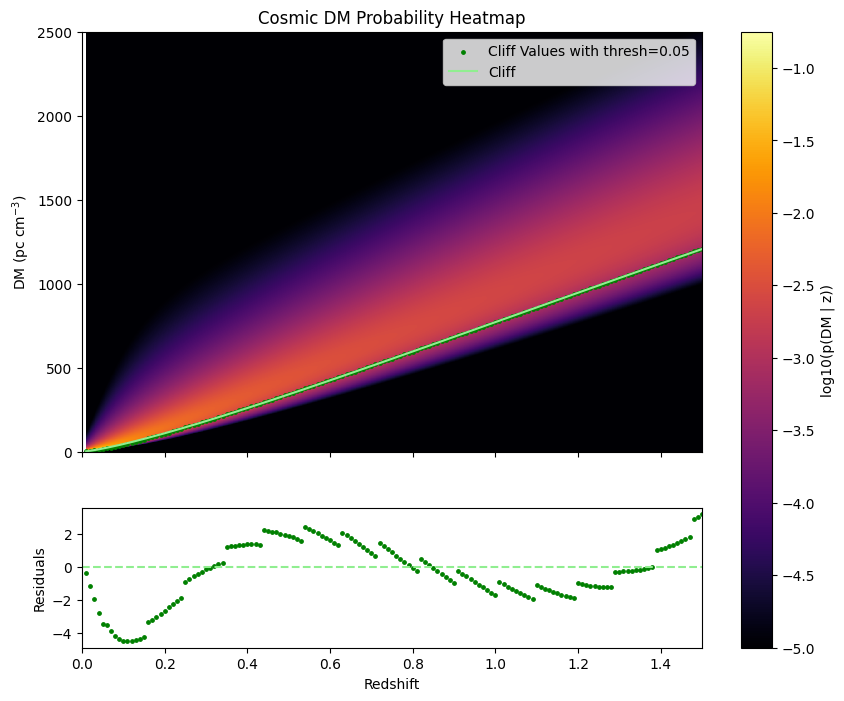

In [12]:
fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(10, 8),
                                   sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno", shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=[ax, ax_res], label="log10(p(DM | z))", location='right')
scatter1 = ax.scatter(np.arange(0.01,1.51,0.01), cliff_values[:150], s=6, color="green", label="Cliff Values with thresh=0.05")
ax.plot(red, power_law_quad_correct(red, *cliff_fit_4[0]), color="lightgreen", label="Cliff")
ax.set_ylabel("DM (pc cm$^{-3}$)")
ax.set_title("Cosmic DM Probability Heatmap")
ax.legend(loc="upper right")
ax.set_ylim(0, 2500)

# Residuals
z_fit = np.arange(0.01, 1.51, 0.01)
residuals = cliff_values[:150] - power_law_quad_correct(z_fit, *cliff_fit_4[0])
ax_res.scatter(z_fit, residuals, s=6, color="green")
ax_res.axhline(0, color="lightgreen", linestyle="--")
ax_res.set_ylabel("Residuals")
ax_res.set_xlabel("Redshift")

ax.set_xlim(0, 1.5)
ax_res.set_xlim(0, 1.5)
plt.show()

In [23]:
def power_law_sin_correct(x,a,b,c):
    return a * x**b + c * np.sin(x)
cliff_fit_5 = curve_fit(power_law_sin_correct, np.arange(0.01, 1.51, 0.01), cliff_values[:150], p0=[700,0.8, -20])
print(cliff_fit_5)

(array([537.27909793,   1.3618968 , 276.27235677]), array([[ 1.18270760e+03, -1.60711917e+00, -1.42084245e+03],
       [-1.60711917e+00,  2.18830931e-03,  1.93045724e+00],
       [-1.42084245e+03,  1.93045724e+00,  1.70712802e+03]]))


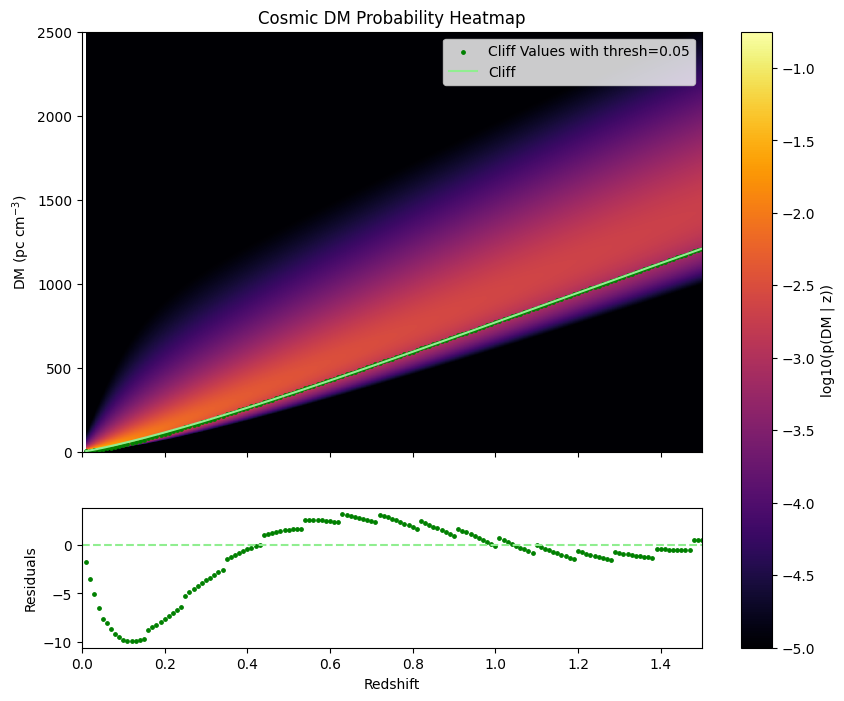

In [24]:
fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(10, 8),
                                   sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno", shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=[ax, ax_res], label="log10(p(DM | z))", location='right')
scatter1 = ax.scatter(np.arange(0.01,1.51,0.01), cliff_values[:150], s=6, color="green", label="Cliff Values with thresh=0.05")
ax.plot(red, power_law_sin_correct(red, *cliff_fit_5[0]), color="lightgreen", label="Cliff")
ax.set_ylabel("DM (pc cm$^{-3}$)")
ax.set_title("Cosmic DM Probability Heatmap")
ax.legend(loc="upper right")
ax.set_ylim(0, 2500)

# Residuals
z_fit = np.arange(0.01, 1.51, 0.01)
residuals = cliff_values[:150] - power_law_sin_correct(z_fit, *cliff_fit_5[0])
ax_res.scatter(z_fit, residuals, s=6, color="green")
ax_res.axhline(0, color="lightgreen", linestyle="--")
ax_res.set_ylabel("Residuals")
ax_res.set_xlabel("Redshift")

ax.set_xlim(0, 1.5)
ax_res.set_xlim(0, 1.5)
plt.show()

In [37]:
def curve(x, a, b, c):
    return a *(x - b)**c

cliff_fit_6 = curve_fit(curve, np.arange(0.01, 1.51, 0.01), cliff_values[:150], p0=[500,-1, 1])
print(cliff_fit_6)

(array([7.73435403e+02, 9.99998884e-03, 1.14001652e+00]), array([[ 7.39568899e+00,  7.36520338e-03, -1.19572904e-02],
       [ 7.36520338e-03,  7.61535583e-06, -1.20175751e-05],
       [-1.19572904e-02, -1.20175751e-05,  2.34118162e-05]]))


/tmp/ipykernel_2164/2491178893.py:2: RuntimeWarning: invalid value encountered in power
  return a *(x - b)**c


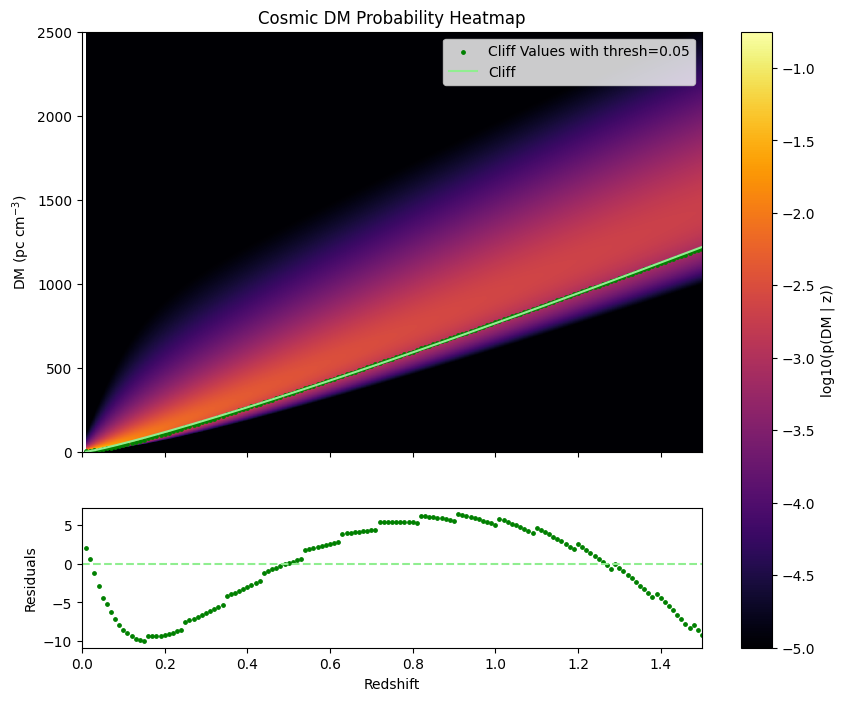

In [38]:
ig, (ax, ax_res) = plt.subplots(2, 1, figsize=(10, 8),
                                   sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno", shading="nearest",
    vmax=-0.75, vmin=-5.0
)

plt.colorbar(im, ax=[ax, ax_res], label="log10(p(DM | z))", location='right')
scatter1 = ax.scatter(np.arange(0.01,1.51,0.01), cliff_values[:150], s=6, color="green", label="Cliff Values with thresh=0.05")
ax.plot(red, curve(red, *cliff_fit_6[0]), color="lightgreen", label="Cliff")
ax.set_ylabel("DM (pc cm$^{-3}$)")
ax.set_title("Cosmic DM Probability Heatmap")
ax.legend(loc="upper right")
ax.set_ylim(0, 2500)

# Residuals
z_fit = np.arange(0.01, 1.51, 0.01)
residuals = cliff_values[:150] - curve(z_fit, *cliff_fit_6[0])
ax_res.scatter(z_fit, residuals, s=6, color="green")
ax_res.axhline(0, color="lightgreen", linestyle="--")
ax_res.set_ylabel("Residuals")
ax_res.set_xlabel("Redshift")

ax.set_xlim(0, 1.5)
ax_res.set_xlim(0, 1.5)
plt.show()

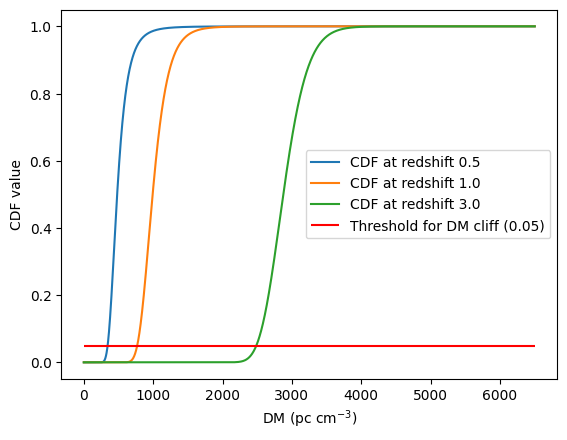

In [27]:
plt.plot(dm_c,cdf_values[49], label="CDF at redshift 0.5" )
plt.plot(dm_c,cdf_values[99], label="CDF at redshift 1.0" )
plt.plot(dm_c,cdf_values[299], label="CDF at redshift 3.0" )
plt.hlines(0.05, xmin=0, xmax=6500, color="red", label="Threshold for DM cliff (0.05)")
plt.legend(loc="center right")
plt.xlabel("DM (pc cm$^{-3})$")
plt.ylabel("CDF value")
plt.show()

# Mean and Standard Deviation

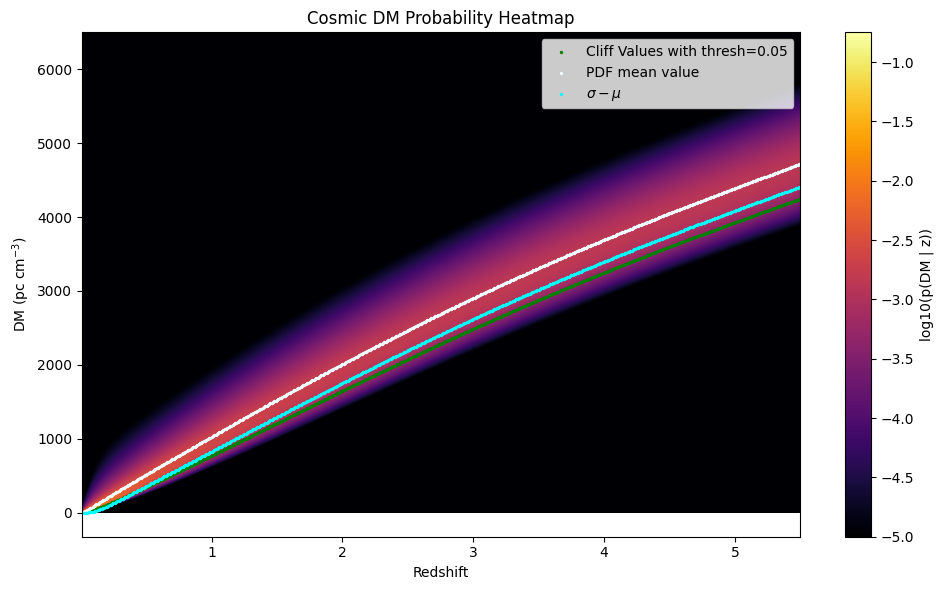

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)
express=[means[i] - sds[i] for i in range(len(means))]
scatter1= ax.scatter(np.arange(0.01,5.51,0.01),cliff_values, s=2, color="green", label="Cliff Values with thresh=0.05")
scatter2=ax.scatter(np.arange(0.01,5.51,0.01), means, s=2, color="azure", label="PDF mean value")
scatter3=ax.scatter(np.arange(0.01,5.51,0.01), express, s=2, color="cyan", label="$\sigma-\mu$")
plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

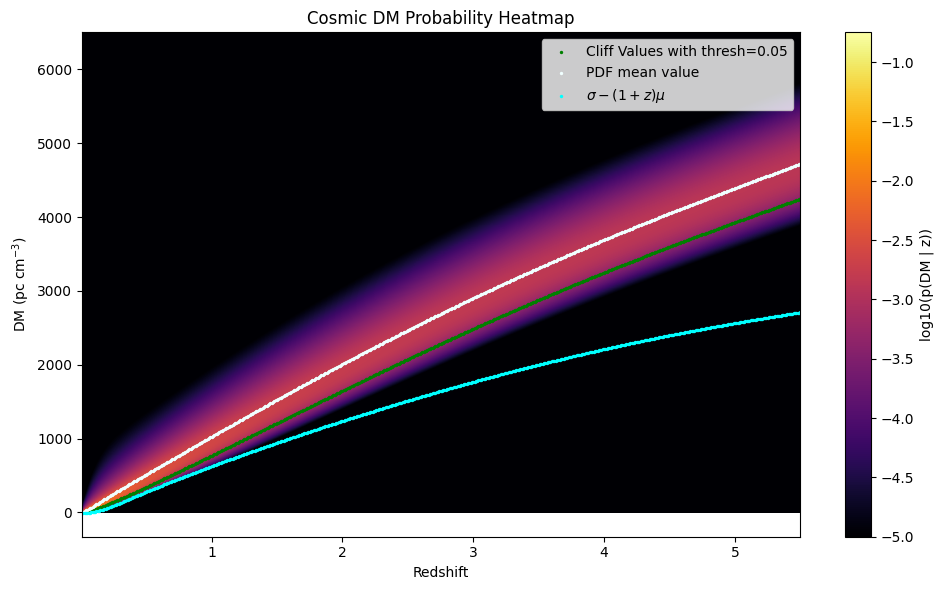

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)
z = np.arange(0.01, 5.51, 0.01)
express=means - (1+z) *sds
scatter1= ax.scatter(np.arange(0.01,5.51,0.01),cliff_values, s=2, color="green", label="Cliff Values with thresh=0.05")
scatter2=ax.scatter(np.arange(0.01,5.51,0.01), means, s=2, color="azure", label="PDF mean value")
scatter3=ax.scatter(np.arange(0.01,5.51,0.01), express, s=2, color="cyan", label="$\sigma-(1+z)\mu$")
plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

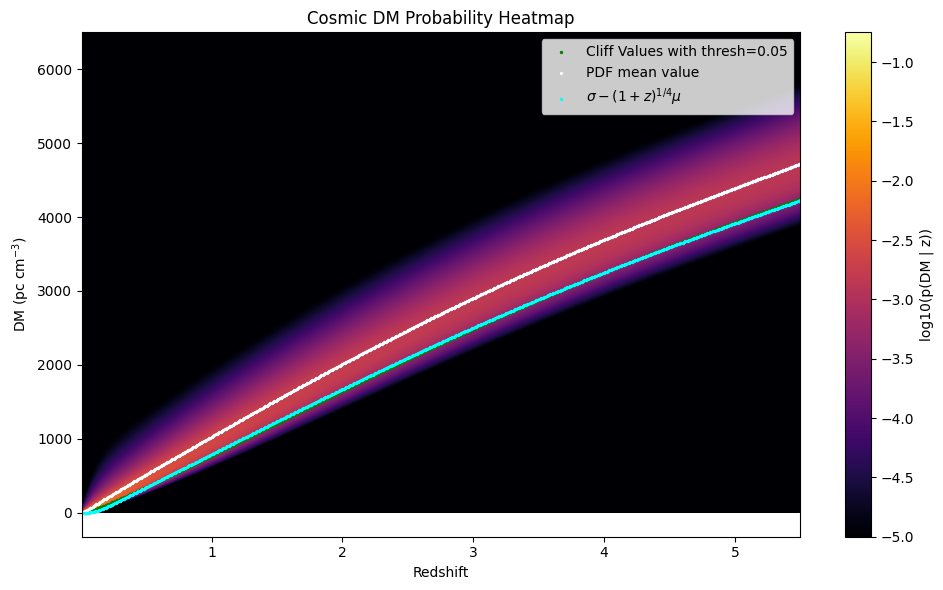

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)
express=means - (1+z)**(1/4)*sds 
scatter1= ax.scatter(np.arange(0.01,5.51,0.01),cliff_values, s=2, color="green", label="Cliff Values with thresh=0.05")
scatter2=ax.scatter(np.arange(0.01,5.51,0.01), means, s=2, color="azure", label="PDF mean value")
scatter3=ax.scatter(np.arange(0.01,5.51,0.01), express, s=2, color="cyan", label="$\sigma-(1+z)^{1/4}\mu$")
plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

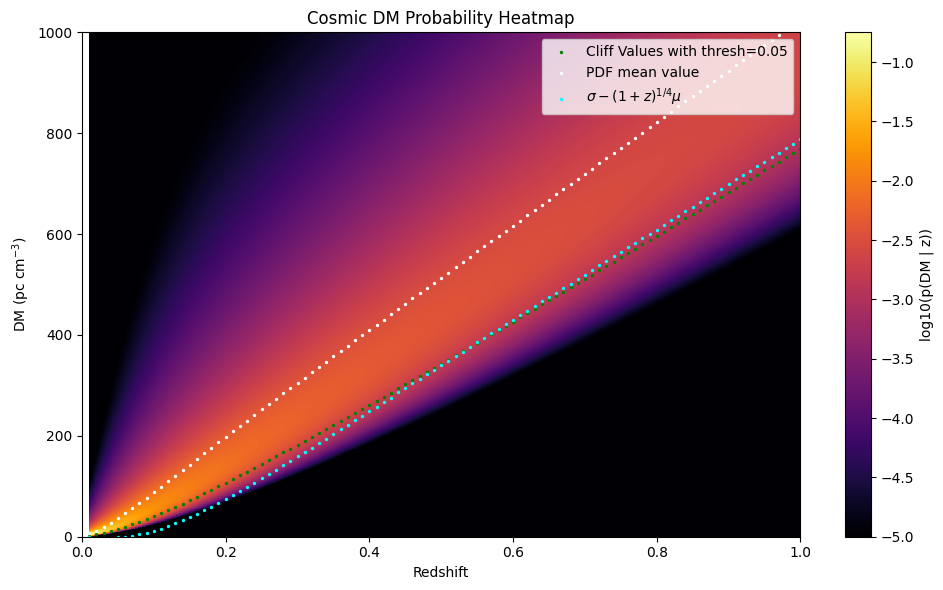

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.pcolormesh(
    red, dm_c, np.log10(cosmic+1e-32),
    cmap="inferno",
    shading="nearest",
    vmax=-0.75, vmin=-5.0
)
express=means - (1+z)**(1/4)*sds 
scatter1= ax.scatter(np.arange(0.01,5.51,0.01),cliff_values, s=2, color="green", label="Cliff Values with thresh=0.05")
scatter2=ax.scatter(np.arange(0.01,5.51,0.01), means, s=2, color="azure", label="PDF mean value")
scatter3=ax.scatter(np.arange(0.01,5.51,0.01), express, s=2, color="cyan", label="$\sigma-(1+z)^{1/4}\mu$")
plt.colorbar(im, ax=ax, label="log10(p(DM | z))")
ax.set_ylabel("DM (pc cm$^{-3})$")
ax.set_xlabel("Redshift")
ax.set_title("Cosmic DM Probability Heatmap")
plt.legend(loc="upper right")
plt.tight_layout()
plt.xlim(0,1)
plt.ylim(0,1000)
plt.show()